In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
dft=pd.read_csv('/content/student_data (1).csv', encoding='ISO-8859-1')
dft

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [39]:
dft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


In [40]:
dft.drop('Unnamed: 0', axis=1,)
dft

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [41]:
dft['TotalScore']=dft['MathScore']+dft['ReadingScore']+dft['WritingScore']
dft

,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore,TotalScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74,216
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88,247
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91,271
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42,143
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65,185
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51,162
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67,198
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93,265


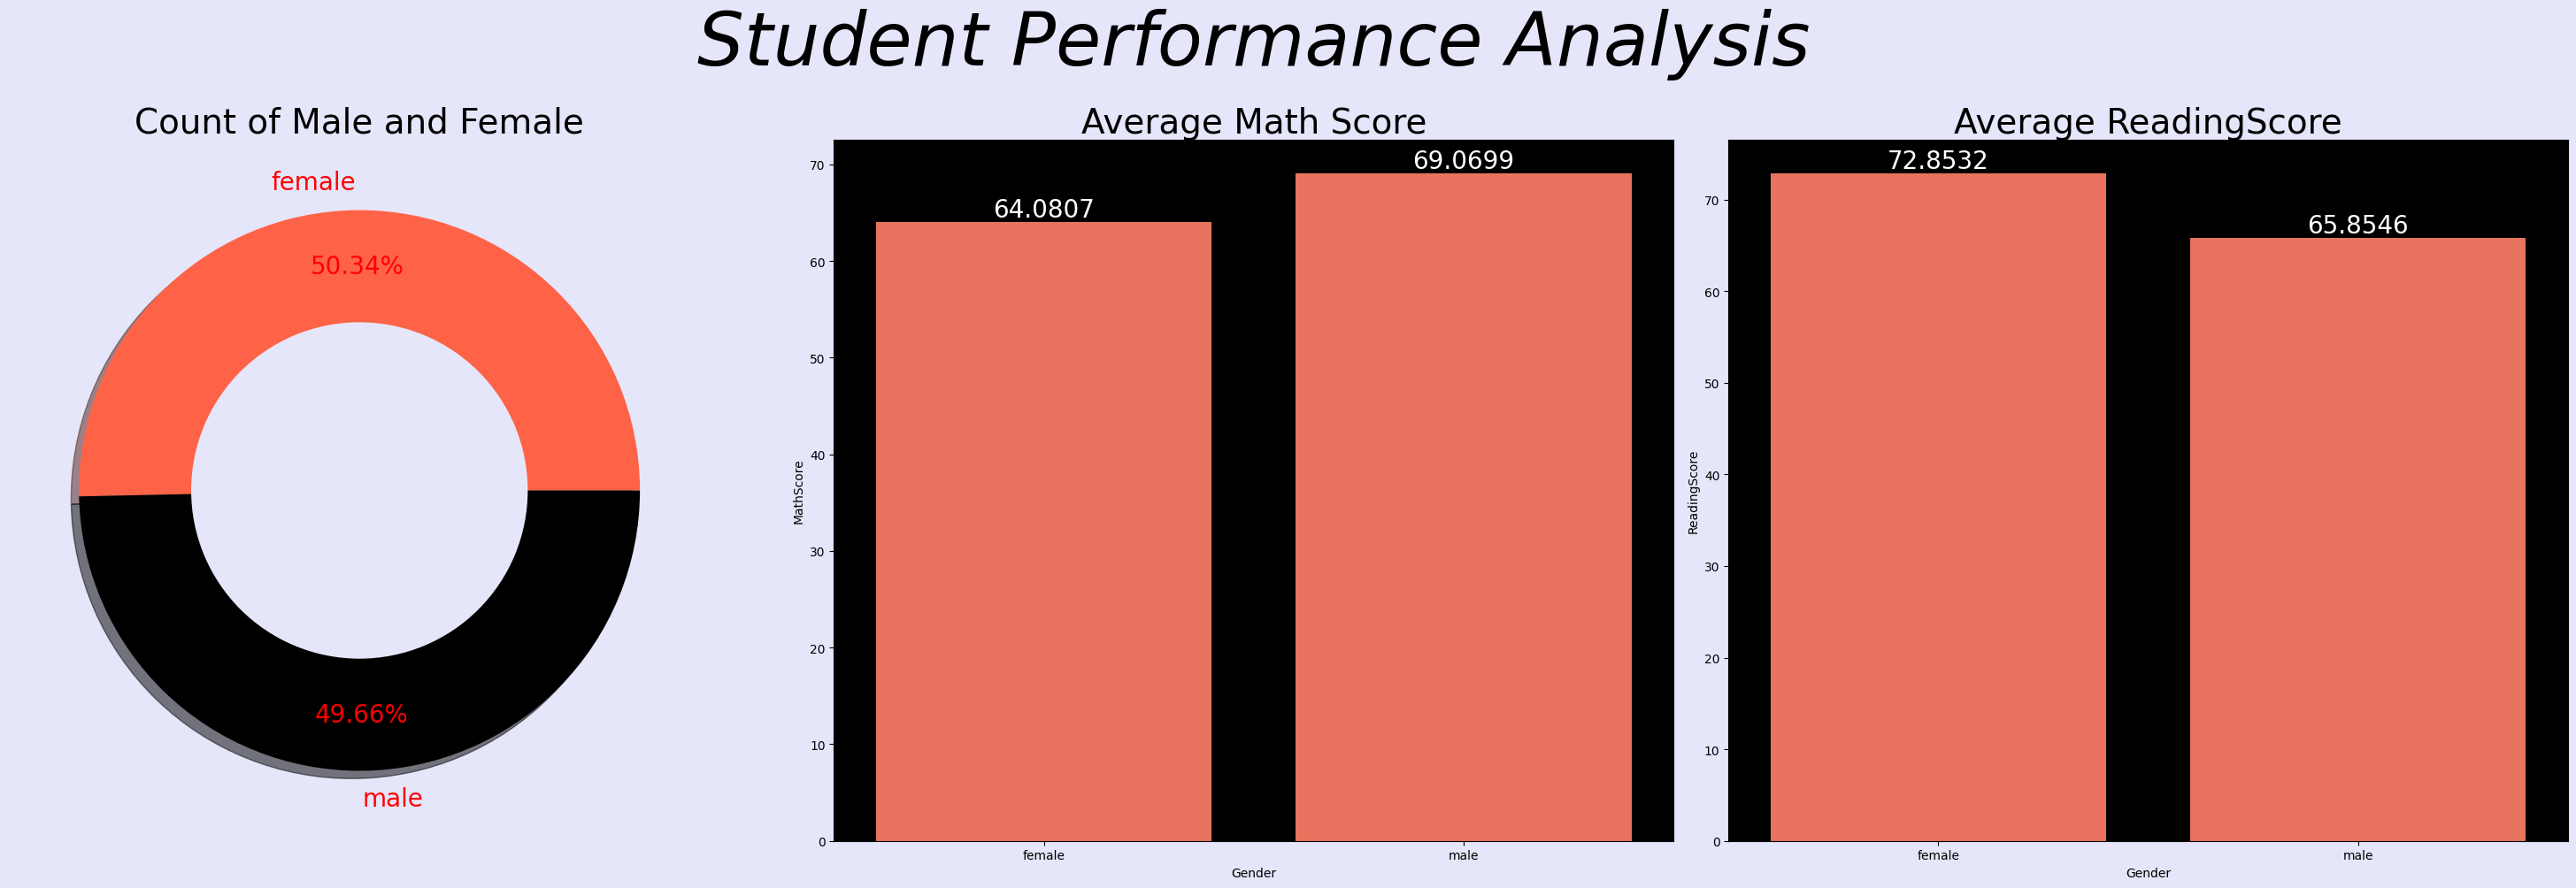

In [42]:
plt.figure(figsize=(30,10),facecolor='lavender')

plt.subplot(1,3,1)
gc=dft['Gender'].value_counts()
color1=['tomato','black']
plt.pie(gc,labels=gc.index,autopct='%0.2f%%',shadow=True,explode=[0,0],colors=color1,textprops={'fontsize':20,'color':'red'},pctdistance=0.8)
plt.pie([1],radius=0.6,colors=['lavender'])
plt.title('Count of Male and Female',fontsize=28)

plt.subplot(1,3,2)
sg=dft.groupby('Gender',as_index=False)['MathScore'].mean()
a=sns.barplot(x='Gender',y='MathScore',data=sg,color='tomato')
for i in a.containers:
  a.bar_label(i,color='white',fontsize=20)
plt.gca().set_facecolor('black')
plt.title('Average Math Score',fontsize=28)

plt.subplot(1,3,3)
sg=dft.groupby('Gender',as_index=False)['ReadingScore'].mean()
a=sns.barplot(x='Gender',y='ReadingScore',data=sg,color='tomato')
for i in a.containers:
  a.bar_label(i,color= 'white',fontsize=20)
plt.gca().set_facecolor('black')
plt.title('Average ReadingScore',fontsize=28)

plt.gcf().suptitle('Student Performance Analysis',fontsize=60,fontstyle='italic',ha='center',x=0.5,y=1)
plt.tight_layout()
plt.show()

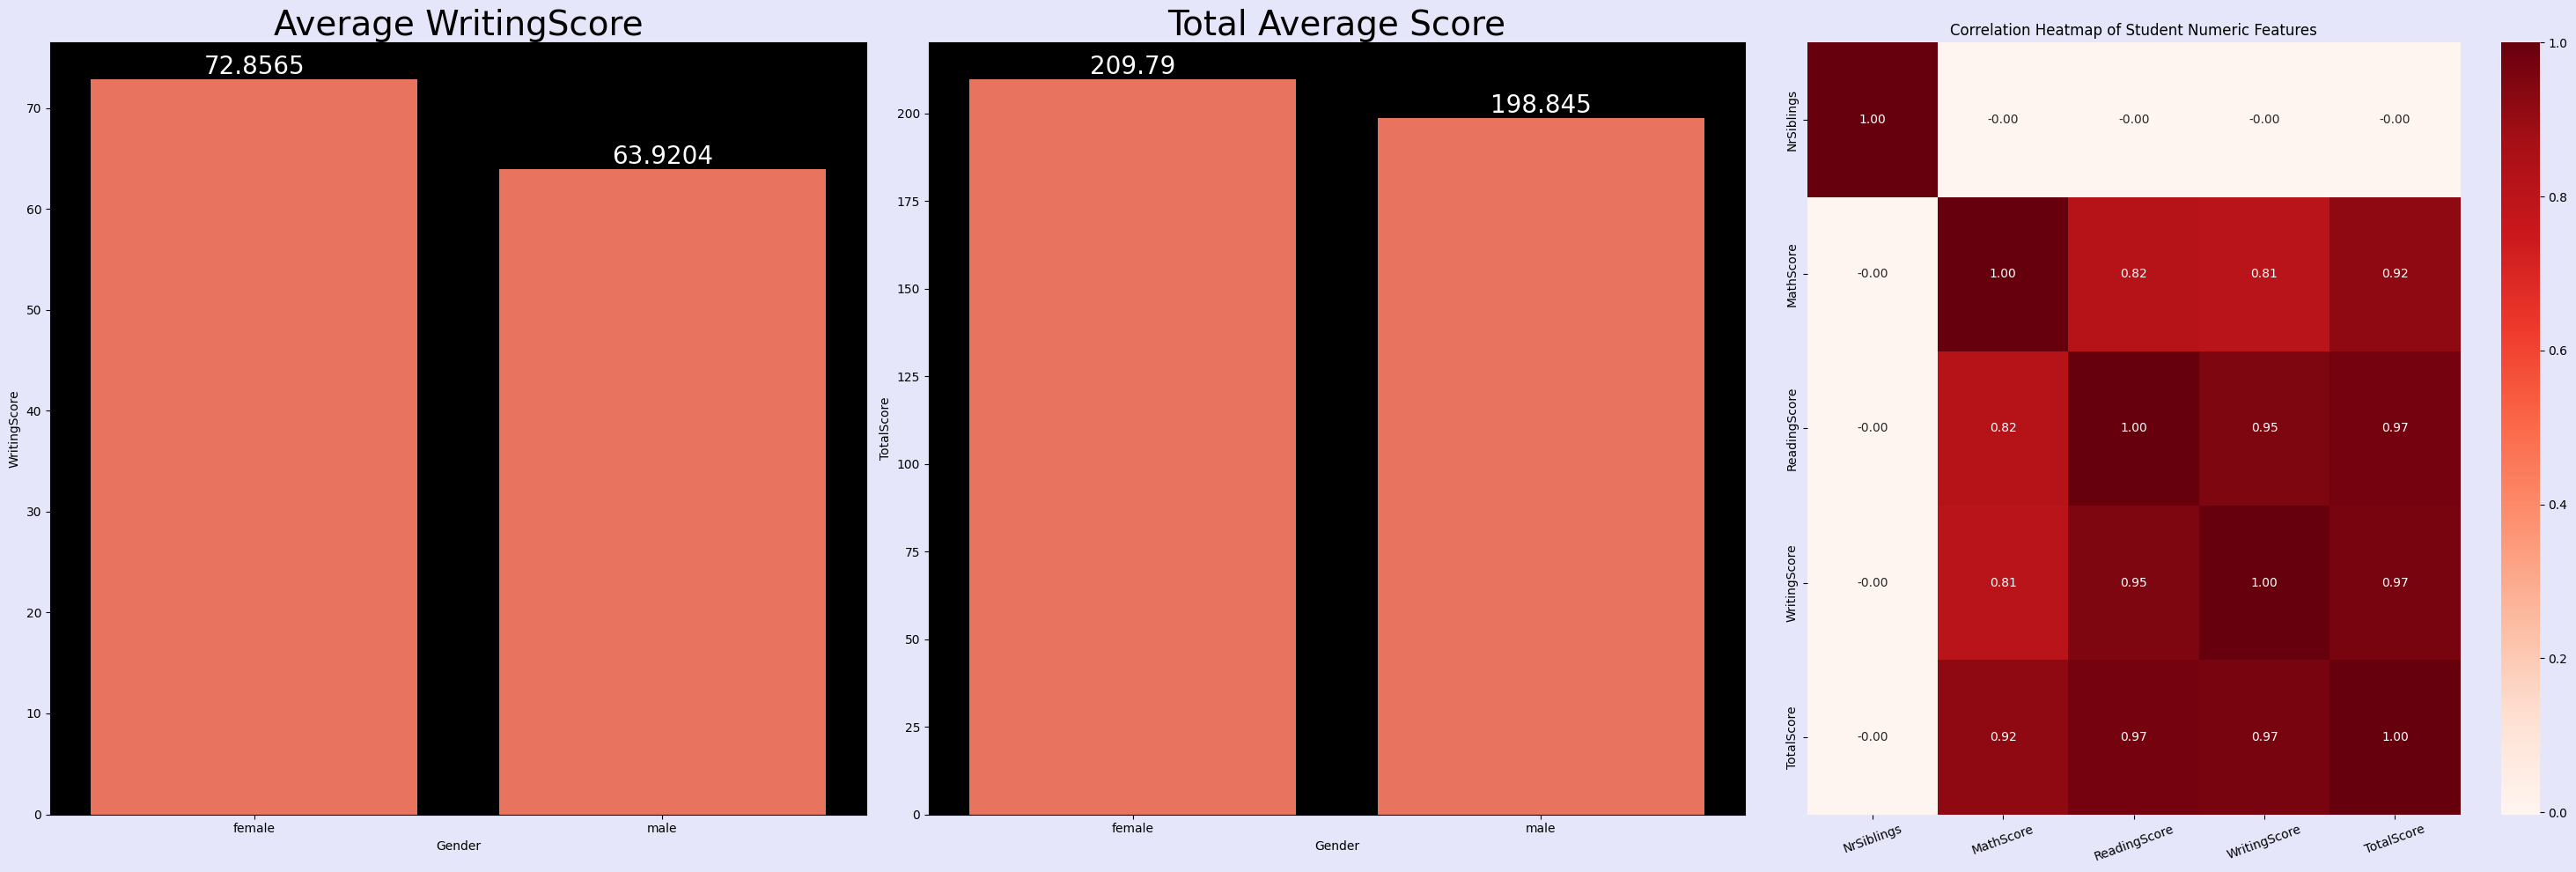

In [43]:
plt.figure(figsize=(30,10),facecolor='lavender')

plt.subplot(1,3,1)
sg=dft.groupby('Gender',as_index=False)['WritingScore'].mean()
a=sns.barplot(x='Gender',y='WritingScore',data=sg,color='tomato')
for i in a.containers:
  a.bar_label(i,color='white',fontsize=20)
plt.gca().set_facecolor('black')
plt.title('Average WritingScore',fontsize=28)

plt.subplot(1,3,2)
sg=dft.groupby('Gender',as_index=False)['TotalScore'].mean()
a=sns.barplot(x='Gender',y='TotalScore',data=sg,color='tomato')
for i in a.containers:
  a.bar_label(i,color='white',fontsize=20)
plt.gca().set_facecolor('black')
plt.title('Total Average Score',fontsize=28)

plt.subplot(1,3,3)
num_cols = ['NrSiblings','MathScore', 'ReadingScore', 'WritingScore', 'TotalScore']
corr = dft[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='Reds', fmt='0.2f')
plt.title('Correlation Heatmap of Student Numeric Features')
plt.gca().set_facecolor('black')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

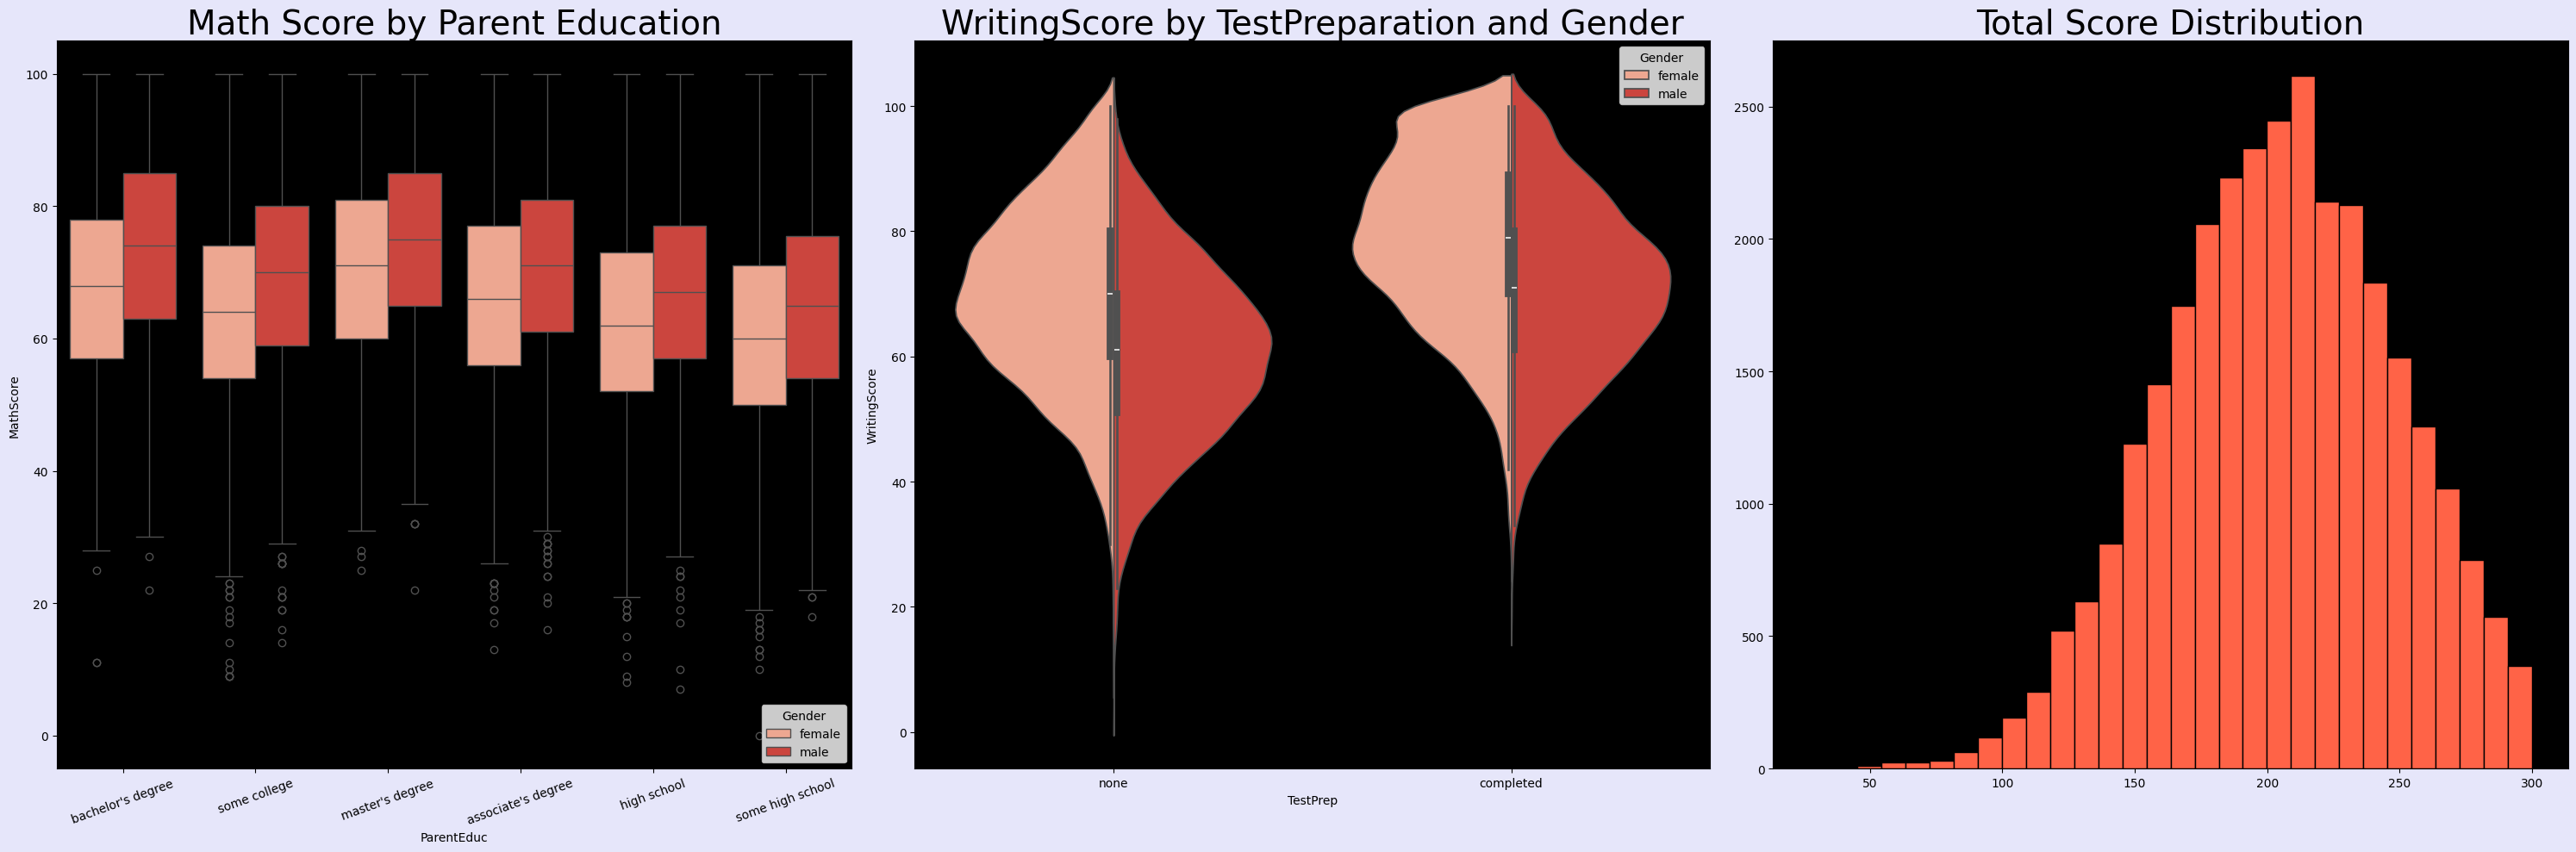

In [44]:
plt.figure(figsize=(30,10),facecolor='lavender')

plt.subplot(1,3,1)
sns.boxplot(x='ParentEduc', y='MathScore', data=dft,hue='Gender', palette='Reds')
plt.title('Math Score by Parent Education', fontsize=28)
plt.gca().set_facecolor('black')
plt.xticks(rotation=20)

plt.subplot(1,3,2)
sns.violinplot(x='TestPrep', y='WritingScore', data=dft, hue='Gender', split=True, palette='Reds')
plt.title('WritingScore by TestPreparation and Gender', fontsize=28)
plt.gca().set_facecolor('black')


plt.subplot(1,3,3)
a=plt.hist(dft['TotalScore'], bins=30, color='tomato', edgecolor='black')
plt.title('Total Score Distribution', fontsize=28)
plt.gca().set_facecolor('black')

plt.tight_layout()
plt.show()